# CBECS 2018 Building Energy Performance: Data Inspection, Cleaning, and EDA

This notebook implements the data preparation and exploratory analysis stage described in the interim report. It runs in six parts:

1. **Data inspection** — confirm shape, types, and missingness before any values are changed
2. **Data cleaning** — encode ordinal variables correctly, recode structurally missing HVAC fields, exclude undefined-EUI records, and derive EUI
3. **Survey design effect** — validate the JK2 replicate weights and quantify the design effect for mean log EUI
4. **Univariate EDA** — one variable at a time: distributions, summary statistics, frequency tables
5. **Bivariate EDA** — each predictor against log site EUI: correlations, scatterplots, grouped boxplots
6. **Predictor matrix assembly** — the model-ready matrix shared by RQ1 and RQ3, plus a staged feature-engineered variant for the RQ1 modelling phase

Every plot is written to `output/figures/` and every summary table to `output/tables/` as a CSV, in addition to rendering inline, so individual figures and tables can be pasted into the interim or final report without re-running the analysis.

**Using this notebook from the project's GitHub repository.** The repository ([Shaman2320/QM640_Capstone_BuildingEnergyPerfromance](https://github.com/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance)) keeps the raw microdata at `data/raw/cbecs2018_final_public.csv`, notebooks and scripts under `src/`, and generated artifacts under `output/`. By default this notebook reads the CSV directly from GitHub via its `raw.githubusercontent.com` URL, so it runs anywhere (including Colab) without cloning. To run against a local clone instead, set `USE_GITHUB_RAW = False` and run from the repository root so the relative path in `INPUT_CSV` resolves.

## 1. Setup and Configuration

In [17]:
# --- Colab bootstrap: run only when in Colab ---
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")   # store this in Colab Secrets
    repo = "Shaman2320/QM640_Capstone_BuildingEnergyPerfromance"
    if not os.path.isdir("/content/repo"):
        os.system(f"git clone https://{token}@github.com/{repo}.git /content/repo")
    os.chdir("/content/repo")
    os.system('git config user.email "sharathmoh@gmail.com"')
    os.system('git config user.name  "Shaman2320"')

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---- Data source ----------------------------------------------------------
# Default: read the CSV straight from the project repository on GitHub.
USE_GITHUB_RAW = True
GITHUB_RAW_CSV_URL = "https://raw.githubusercontent.com/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance/main/data/raw/cbecs2018_final_public.csv"

# Fallback: local path relative to the repository root, used when
# USE_GITHUB_RAW = False and the repo has been cloned.
INPUT_CSV = "data/raw/cbecs2018_final_public.csv"

# ---- Output locations -----------------------------------------------------
# Matches the repository's output/ folder so generated artifacts can be
# committed alongside the data and code.
FIG_DIR = "output/figures"
TAB_DIR = "output/tables"

# The seventeen analysis variables specified in the synopsis (Table 2),
# grouped by role so the cleaning and EDA steps below can address each
# group with the treatment it actually needs.
ID_VARS = ["PUBID"]
CONTINUOUS_VARS = ["SQFT", "FLCEILHT", "WKHRS", "NWKER", "HDD65", "CDD65"]
ORDINAL_VARS = ["NFLOOR", "YRCONC", "GLSSPC"]
NOMINAL_VARS = ["PBA", "WLCNS", "RFCNS", "MAINHT", "MAINCL", "OPEN24"]
WEIGHT_VAR = "FINALWT"
FUEL_VAR = "MFBTU"

# ---- Figure labelling -----------------------------------------------------
# Full display names for every analysis variable, so every chart reads
# without a codebook (no CBECS short forms on axes or titles).
FULL_NAMES = {
    "SQFT": "Floor Area (sq ft)",
    "FLCEILHT": "Floor-to-Ceiling Height (ft)",
    "WKHRS": "Weekly Operating Hours",
    "NWKER": "Number of Workers (main shift)",
    "HDD65": "Heating Degree Days (base 65\u00b0F)",
    "CDD65": "Cooling Degree Days (base 65\u00b0F)",
    "NFLOOR": "Number of Floors",
    "YRCONC": "Construction Vintage (CBECS category)",
    "GLSSPC": "Glazing Percentage Band",
    "PBA": "Principal Building Activity",
    "WLCNS": "Wall Construction Material (CBECS code)",
    "RFCNS": "Roof Construction Material (CBECS code)",
    "MAINHT": "Main Heating Equipment (CBECS code, 0 = none reported)",
    "MAINCL": "Main Cooling Equipment (CBECS code, 0 = none reported)",
    "OPEN24": "Open 24 Hours a Day",
    "EUI": "Site Energy Use Intensity (kBtu per sq ft per year)",
    "log_EUI": "Natural Log of Site Energy Use Intensity",
}

def label_of(col):
    return FULL_NAMES.get(col, col)

# Category labels where the CBECS coding is unambiguous and verified
# against the 2018 codebook; other categoricals keep their numeric codes
# with the code convention stated in the axis label instead.
PBA_LABELS = {
    1: "Vacant", 2: "Office", 4: "Laboratory", 5: "Nonrefrigerated warehouse",
    6: "Food sales", 7: "Public order and safety", 8: "Outpatient health care",
    11: "Refrigerated warehouse", 12: "Religious worship", 13: "Public assembly",
    14: "Education", 15: "Food service", 16: "Inpatient health care",
    17: "Nursing", 18: "Lodging", 23: "Strip shopping mall", 24: "Enclosed mall",
    25: "Retail (other than mall)", 26: "Service", 91: "Other",
}
OPEN24_LABELS = {1: "Open 24 hours", 2: "Not open 24 hours"}
CATEGORY_LABELS = {"PBA": PBA_LABELS, "OPEN24": OPEN24_LABELS}

def map_labels(col, values):
    """Map raw category codes to readable labels where a verified mapping exists."""
    mapping = CATEGORY_LABELS.get(col, {})
    out = []
    for v in values:
        try:
            key = int(v)
        except (TypeError, ValueError):
            key = v
        out.append(str(mapping.get(key, v)))
    return out

# ---- Style ----------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
ACCENT = "#2b7bba"       # primary blue for distributions and scatterplots
ACCENT_ALT = "#2a9d64"   # green for weighted/categorical charts
ACCENT_BOX = "#7fb8a4"   # muted teal for grouped boxplots

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}/")
print(f"Tables will be saved to:  {TAB_DIR}/")

Figures will be saved to: output/figures/
Tables will be saved to:  output/tables/


## 2. Data Inspection

### 2.1 Load Raw Data and Inspect Structure

Before any values are touched, confirm the raw file's shape, dtypes, and missingness. This is the check that catches a bad download or a truncated read before it silently propagates into the cleaned data.

In [19]:
raw = pd.read_csv(GITHUB_RAW_CSV_URL if USE_GITHUB_RAW else INPUT_CSV)
print(f"Raw shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 6436 rows x 1249 columns


,PUBID,REGION,CENDIV,PBA,PUBCLIM,SQFT,SQFTC,WLCNS,RFCNS,RFCOOL,...,ZMFBTU,ZMFEXP,ZELCNS,ZELEXP,ZNGCNS,ZNGEXP,ZFKCNS,ZFKEXP,ZDHBTU,ZDHEXP
0,1,3,5,2,3,210000,8,1,4,2,...,0,0,0,0,9,9,1,1,0,0
1,2,4,9,2,4,28000,5,1,6,1,...,0,0,0,0,0,0,9,9,9,9
2,3,3,5,8,4,2100,2,1,4,2,...,0,0,0,0,9,9,9,9,9,9
3,4,3,7,5,5,240000,8,2,6,1,...,0,0,0,0,1,1,9,9,9,9
4,5,1,2,5,3,295000,8,3,6,2,...,0,0,0,0,0,0,9,9,9,9


**Observation.** The file loads at 6,436 rows by 1,249 columns, matching the dimensions EIA documents for the December 2022 revision of the microdata, so the correct release was retrieved and nothing was truncated in transit. The first rows show the expected one-building-per-record layout keyed by PUBID.

In [20]:
analysis_cols = ID_VARS + CONTINUOUS_VARS + ORDINAL_VARS + NOMINAL_VARS + [WEIGHT_VAR, FUEL_VAR]
missing_present = [c for c in analysis_cols if c not in raw.columns]
if missing_present:
    raise KeyError(f"Expected analysis columns not found in file: {missing_present}")

subset = raw[analysis_cols]
inspection = pd.DataFrame({
    "dtype": subset.dtypes.astype(str),
    "n_non_null": subset.notna().sum(),
    "n_missing": subset.isna().sum(),
    "pct_missing": (subset.isna().mean() * 100).round(2),
    "n_unique": subset.nunique(),
})
inspection.to_csv(os.path.join(TAB_DIR, "01_raw_variable_inspection.csv"))
inspection

,dtype,n_non_null,n_missing,pct_missing,n_unique
PUBID,int64,6436,0,0.00,6436
SQFT,int64,6436,0,0.00,410
FLCEILHT,int64,6436,0,0.00,41
WKHRS,int64,6436,0,0.00,143
NWKER,int64,6436,0,0.00,356
HDD65,int64,6436,0,0.00,4407
CDD65,int64,6436,0,0.00,2917
NFLOOR,int64,6436,0,0.00,11
YRCONC,int64,6436,0,0.00,8
GLSSPC,int64,6436,0,0.00,6


**Observation.** Of the seventeen analysis variables, only three carry any missingness in the raw file: MAINHT (429 records, 6.67 percent), MAINCL (456, 7.09 percent), and MFBTU (79, 1.23 percent). Everything else is fully populated, which reflects EIA's imputation of most fields before public release. Each of the three gaps gets a deliberate treatment in the cleaning step below rather than a default drop.

### 2.2 Validate Sampling Weights

Reconstruct the weighted population total from `FINALWT` and compare it against the EIA-published estimate of 5.9 million commercial buildings. A large discrepancy here would indicate a merge error or a truncated read, so this check runs before any records are dropped.

In [21]:
weighted_buildings_millions = raw[WEIGHT_VAR].sum() / 1_000_000
weighted_floorspace_millions_sqft = (raw[WEIGHT_VAR] * raw["SQFT"]).sum() / 1_000_000

weight_summary = pd.DataFrame({
    "metric": ["weighted_buildings_millions", "weighted_floorspace_million_sqft"],
    "value": [round(weighted_buildings_millions, 3), round(weighted_floorspace_millions_sqft, 0)],
})
weight_summary.to_csv(os.path.join(TAB_DIR, "02_weight_validation.csv"), index=False)
weight_summary

,metric,value
0,weighted_buildings_millions,5.918
1,weighted_floorspace_million_sqft,96527.000


**Observation.** Summing FINALWT reconstructs 5.918 million buildings and 96,527 million square feet of floorspace, within 0.3 percent of the EIA-published totals. Because FINALWT is calibrated to reproduce those totals, this agreement is a necessary check that no records were lost or misjoined during ingestion, and it passes before any cleaning has altered the file.

## 3. Data Cleaning

The cleaning steps run in the order that avoids inconsistent intermediate states: exclude undefined-EUI records first, then recode structural missingness, then fix variable types, then derive EUI.

In [22]:
df = raw.copy()

# Exclude buildings with no reported major-fuel consumption: EUI is
# undefined for these records, not merely missing, so they cannot be
# imputed and must be dropped before EUI is computed.
n_before = len(df)
df = df[df[FUEL_VAR].notna()].copy()
print(f"Dropped {n_before - len(df)} records with undefined MFBTU; {len(df)} remain.")

# MAINHT and MAINCL missingness is treated as structural rather than
# random: a blank main heating/cooling type most plausibly means the
# building has no primary system, which is itself informative for
# small, naturally ventilated, or single-purpose buildings.
df["MAINHT"] = df["MAINHT"].fillna(0)
df["MAINCL"] = df["MAINCL"].fillna(0)

# NFLOOR and GLSSPC are ordered categories, not interval-scaled integers:
# NFLOOR groups tall buildings into codes 994/995 rather than reporting an
# exact floor count, and GLSSPC reports six glazing bands rather than an
# exact percentage. Encoding them as ordered categoricals keeps their
# sequence for models that use it, without implying equal spacing between
# codes that the source data does not support.
for col in ORDINAL_VARS:
    ordered_categories = sorted(df[col].dropna().unique())
    df[col] = pd.Categorical(df[col], categories=ordered_categories, ordered=True)

# Nominal categoricals: cast to pandas category dtype so downstream
# group-by and plotting calls treat them as labels, not numbers.
for col in NOMINAL_VARS:
    df[col] = df[col].astype("category")

# Derive the response variable. EUI is undefined for zero or negative
# floor area, which should not occur in CBECS but is guarded against
# explicitly rather than allowed to produce a silent inf or NaN.
if (df["SQFT"] <= 0).any():
    bad = (df["SQFT"] <= 0).sum()
    raise ValueError(f"{bad} records have non-positive SQFT; investigate before computing EUI.")

df["EUI"] = df[FUEL_VAR] / df["SQFT"]
df["log_EUI"] = np.log(df["EUI"])

print(f"Cleaned analysis sample: {len(df)} buildings")
df.head()

Dropped 79 records with undefined MFBTU; 6357 remain.
Cleaned analysis sample: 6357 buildings


,PUBID,REGION,CENDIV,PBA,PUBCLIM,SQFT,SQFTC,WLCNS,RFCNS,RFCOOL,...,ZELCNS,ZELEXP,ZNGCNS,ZNGEXP,ZFKCNS,ZFKEXP,ZDHBTU,ZDHEXP,EUI,log_EUI
0,1,3,5,2,3,210000,8,1,4,2,...,0,0,9,9,1,1,0,0,141.557867,4.952709
1,2,4,9,2,4,28000,5,1,6,1,...,0,0,0,0,9,9,9,9,61.809107,4.124051
2,3,3,5,8,4,2100,2,1,4,2,...,0,0,9,9,9,9,9,9,24.946190,3.216721
3,4,3,7,5,5,240000,8,2,6,1,...,0,0,1,1,9,9,9,9,13.274062,2.585812
4,5,1,2,5,3,295000,8,3,6,2,...,0,0,0,0,9,9,9,9,15.854268,2.763439


**Observation.** Cleaning removes exactly the 79 records with undefined MFBTU and nothing else, leaving the 6,357-building analysis sample the synopsis anticipated. The MAINHT and MAINCL recodes keep those buildings in the sample rather than imputing a system type they most plausibly do not have, and the ordinal encodings stop NFLOOR's 994/995 codes and GLSSPC's glazing bands from masquerading as interval-scaled numbers in the models that follow.

## 4. Survey Design Effect and Effective Sample Size

In [23]:
# CBECS ships 151 JK2 jackknife replicate weights (FINALWT1..FINALWT151)
# for design-based variance estimation. The design effect (DEFF) compares
# the jackknife variance of the weighted mean of log EUI against the naive
# simple-random-sample variance; a stratified, clustered design like CBECS
# should inflate variance well above 1, and near-zero or degenerate values
# would signal a coding error in the replicate-weight application.
rep_cols = [c for c in df.columns if c.startswith(WEIGHT_VAR) and c != WEIGHT_VAR]
R = len(rep_cols)
print(f"Number of JK2 replicates found: {R}")

theta = np.average(df["log_EUI"], weights=df[WEIGHT_VAR])
replicate_means = np.array([np.average(df["log_EUI"], weights=df[c]) for c in rep_cols])

# JK2 variance with the (R-1)/R scaling, per the CBECS User's Guide recipe
jackknife_var = (R - 1) / R * ((replicate_means - theta) ** 2).sum()
naive_var = df["log_EUI"].var(ddof=1) / len(df)
deff = jackknife_var / naive_var
effective_n = len(df) / deff

print(f"Weighted mean log EUI:                 {theta:.4f}")
print(f"Naive SRS variance of the mean:        {naive_var:.6f}")
print(f"JK2 jackknife variance of the mean:    {jackknife_var:.6f}")
print(f"Design effect (DEFF):                  {deff:.2f}")
print(f"Effective sample size (n / DEFF):      {effective_n:,.0f}")

pd.DataFrame([{
    "n_replicates": R, "weighted_mean_log_EUI": round(theta, 4),
    "naive_srs_variance": round(naive_var, 6), "jackknife_variance": round(jackknife_var, 6),
    "design_effect": round(deff, 2), "effective_n": round(effective_n),
}]).to_csv(os.path.join(TAB_DIR, "08_design_effect.csv"), index=False)

Number of JK2 replicates found: 151
Weighted mean log EUI:                 3.7776
Naive SRS variance of the mean:        0.000138
JK2 jackknife variance of the mean:    0.000847
Design effect (DEFF):                  6.14
Effective sample size (n / DEFF):      1,036


**Observation.** All 151 JK2 replicate weights documented in the CBECS User's Guide are present and produce a jackknife variance of 0.000847 for the mean of log EUI against a naive simple-random-sample variance of 0.000138. The ratio is the design effect, DEFF = 6.14: the stratified, clustered survey design inflates variance roughly sixfold, and the replicate machinery returns sensible, non-degenerate estimates rather than the near-zero values a coding error would produce. The practical consequence is that the effective sample size for mean-based inference is about 1,036 buildings, not 6,357, so confidence intervals for RQ1 and RQ2 will be wider than the nominal sample size suggests.

## 5. Univariate Exploratory Data Analysis

All figures in this and the following sections use full variable names on axes and titles (no CBECS short forms), colour, and readable category labels where the CBECS coding is verified (building activity, 24-hour operation). Categoricals without a verified label mapping keep their numeric codes, with the coding convention stated in the axis label.


### 5.1 Continuous Variables

For each continuous predictor and for EUI itself (raw and logged), a histogram, a boxplot, and a row of summary statistics are produced. Skewness is reported explicitly so the case for log-transforming EUI is documented with a number rather than asserted by eye.

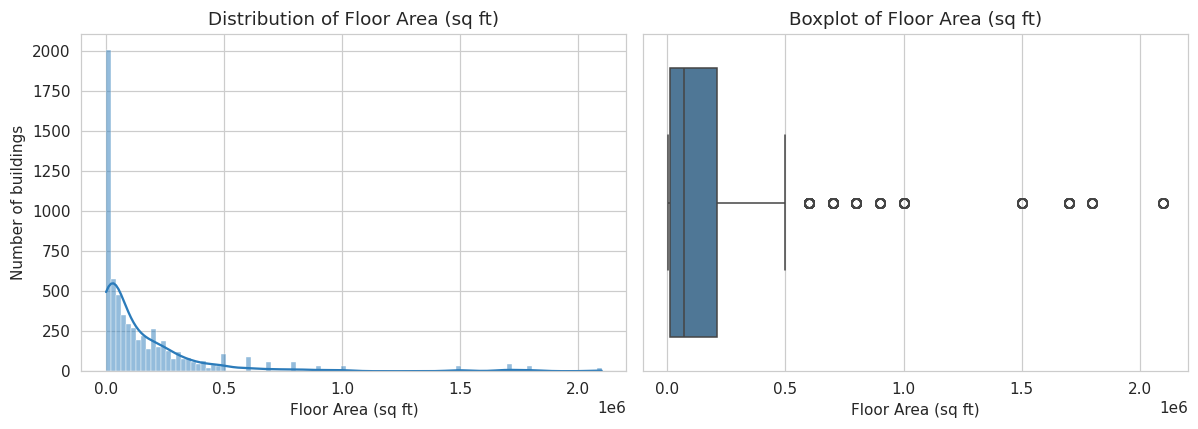

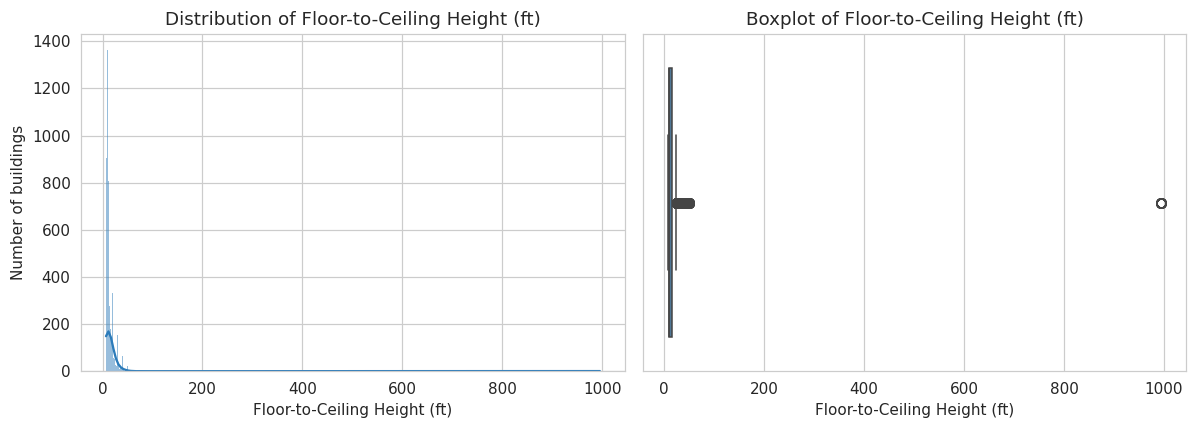

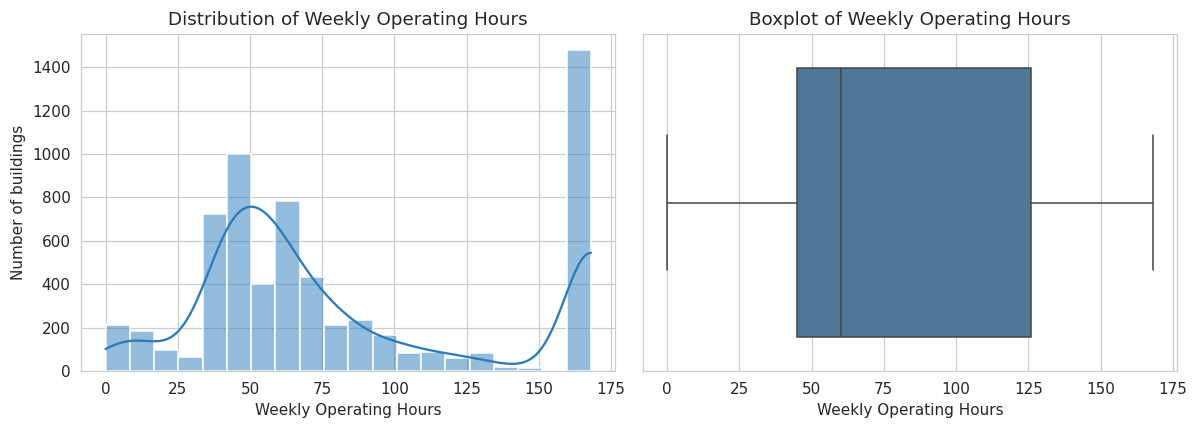

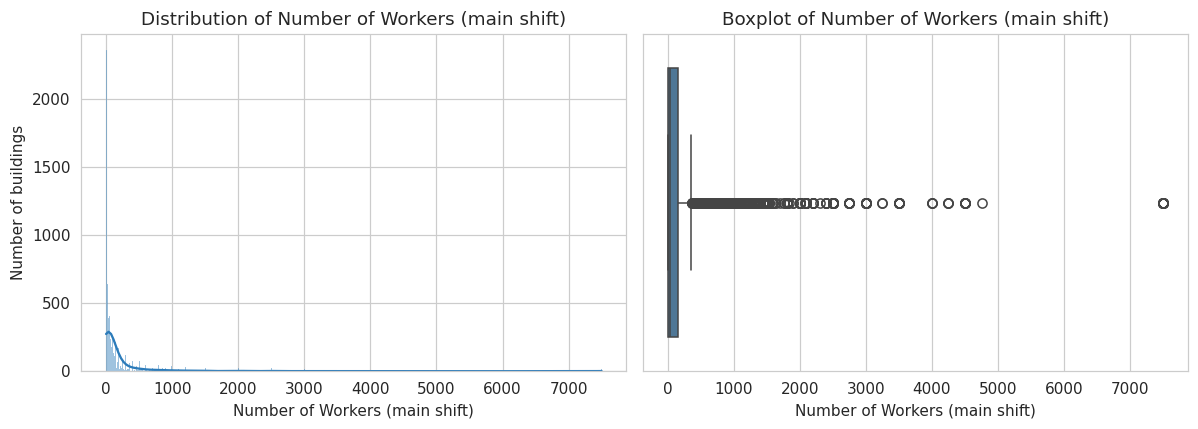

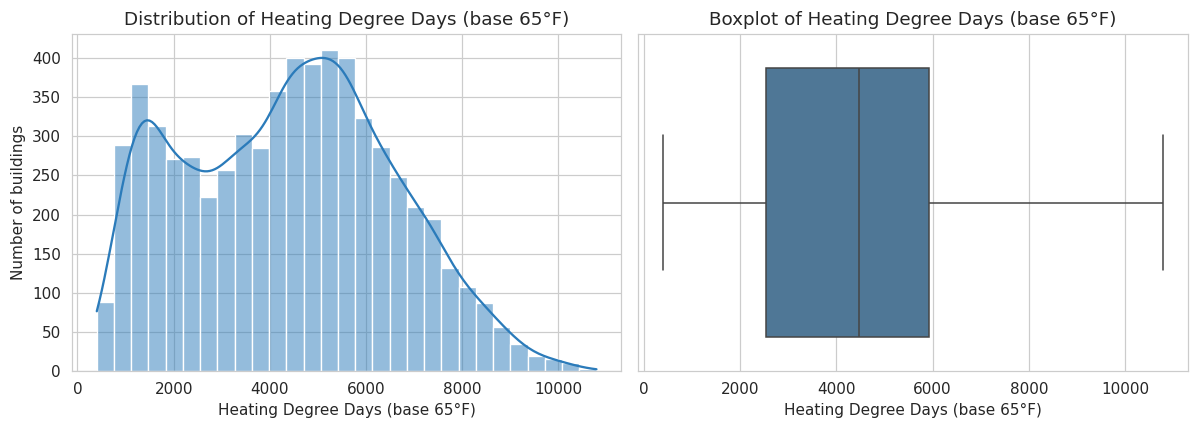

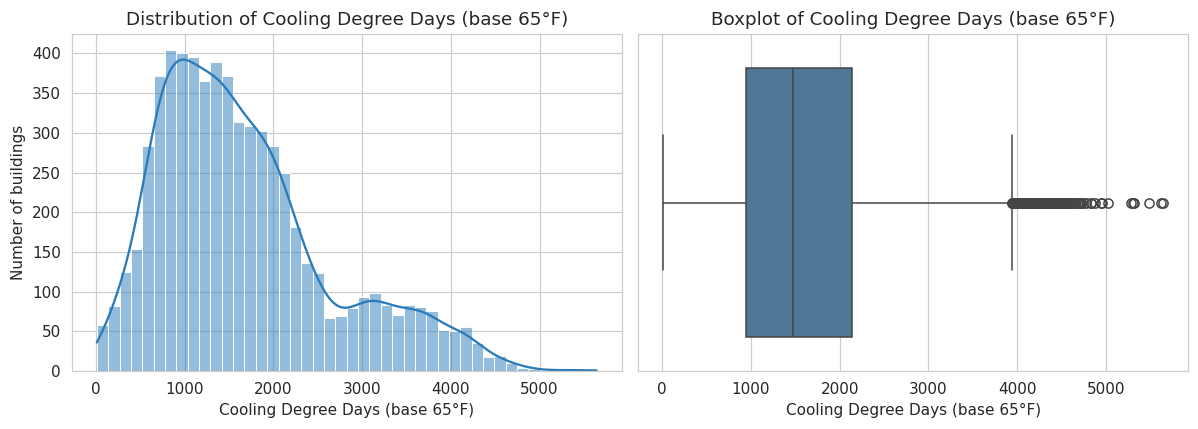

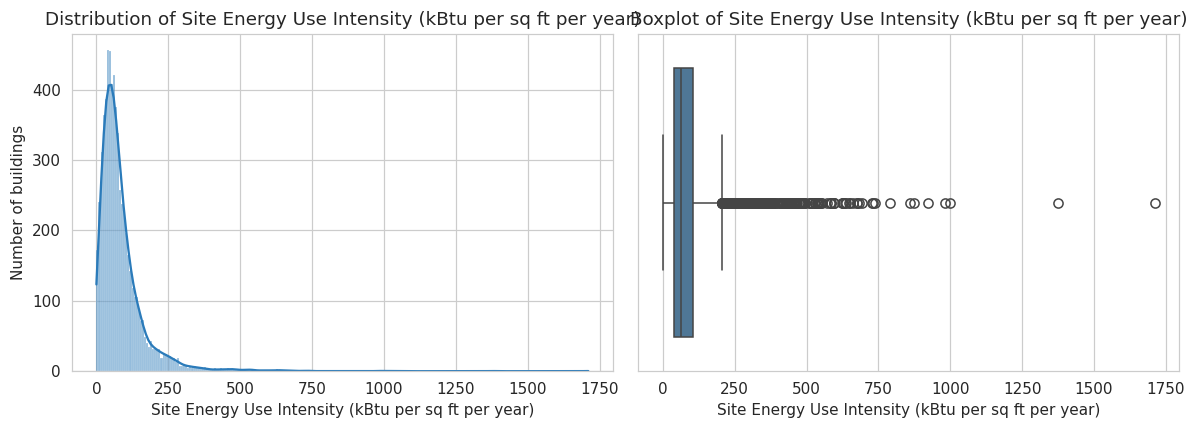

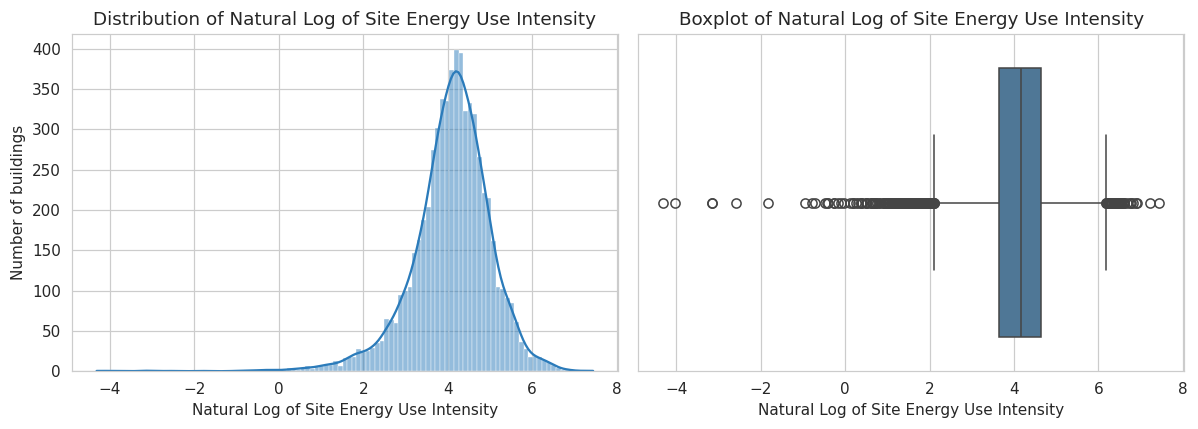

,variable,n,mean,median,sd,min,max,skewness,kurtosis
0,SQFT,6357,170994.197,72000.000,286317.523,1001.000,2100000.000,3.762,17.369
1,FLCEILHT,6357,15.847,10.000,46.561,7.000,995.000,20.490,427.837
2,WKHRS,6357,83.237,60.000,52.434,0.000,168.000,0.642,-0.964
3,NWKER,6357,202.378,40.000,566.757,0.000,7500.000,7.324,74.205
4,HDD65,6357,4380.983,4472.000,2158.640,402.000,10790.000,0.127,-0.761
5,CDD65,6357,1676.525,1471.000,987.142,10.000,5643.000,0.943,0.420
6,EUI,6357,86.043,64.183,87.159,0.013,1710.839,4.556,42.541
7,log_EUI,6357,4.085,4.162,0.937,-4.317,7.445,-1.114,5.223


In [24]:
vars_to_profile = CONTINUOUS_VARS + ["EUI", "log_EUI"]
rows = []

for col in vars_to_profile:
    series = df[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(series, kde=True, ax=axes[0], color=ACCENT)
    axes[0].set_title(f"Distribution of {label_of(col)}")
    axes[0].set_xlabel(label_of(col))
    axes[0].set_ylabel("Number of buildings")
    sns.boxplot(x=series, ax=axes[1], color=ACCENT, saturation=0.5)
    axes[1].set_title(f"Boxplot of {label_of(col)}")
    axes[1].set_xlabel(label_of(col))
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"03_univariate_{col}.png"))
    plt.show()

    rows.append({
        "variable": col,
        "n": series.shape[0],
        "mean": series.mean(),
        "median": series.median(),
        "sd": series.std(),
        "min": series.min(),
        "max": series.max(),
        "skewness": stats.skew(series),
        "kurtosis": stats.kurtosis(series),
    })

continuous_summary = pd.DataFrame(rows).round(3)
continuous_summary.to_csv(os.path.join(TAB_DIR, "03_univariate_continuous_summary.csv"), index=False)
continuous_summary

**Observation.** Two results here matter for the modelling ahead. Raw EUI is heavily right-skewed (skewness 4.556, excess kurtosis 42.541), and the log transform brings those to −1.114 and 5.223: much closer to symmetric, but with tails still heavier than a normal distribution, which sets the expectation against which RQ1's residual diagnostics should be read. FLCEILHT is the anomaly: skewness of 20.490 and kurtosis of 427.837 sit far beyond every other variable and trace to fourteen records carrying 995, the CBECS top-code for more than 50 feet rather than a literal height. Excluding those fourteen drops the two statistics to 2.183 and 5.298, in line with the rest of the table, so the top-code needs recoding or exclusion before FLCEILHT enters a regression as a continuous term.

### 5.2 Categorical Variables

For each categorical or ordinal predictor, the unweighted frequency, the survey-weighted frequency (using `FINALWT`), and a bar chart of the weighted shares are produced. Weighted and unweighted frequencies are reported side by side because CBECS's stratified design means the two can diverge, and a variable that looks balanced in raw counts is not necessarily balanced in the population it represents.

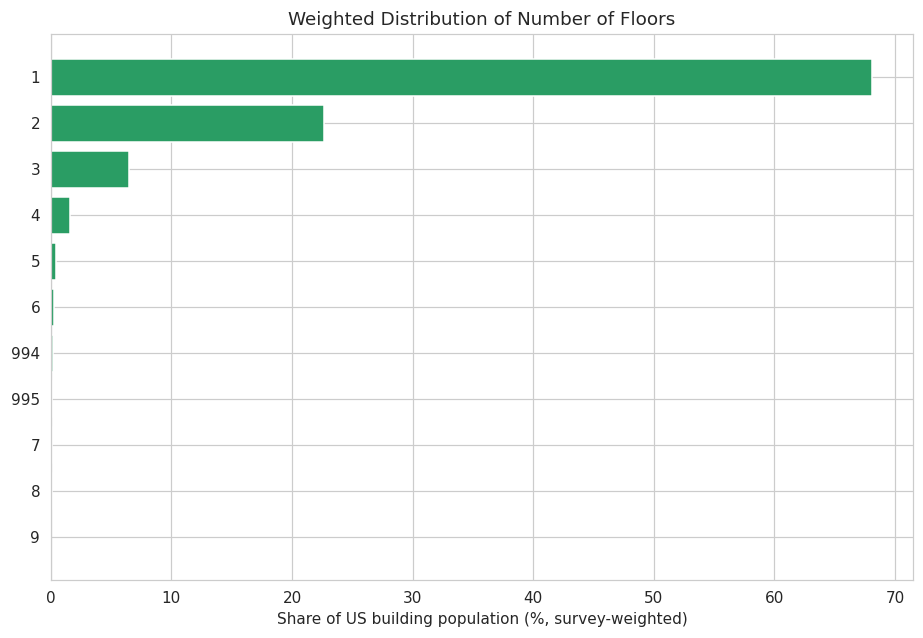

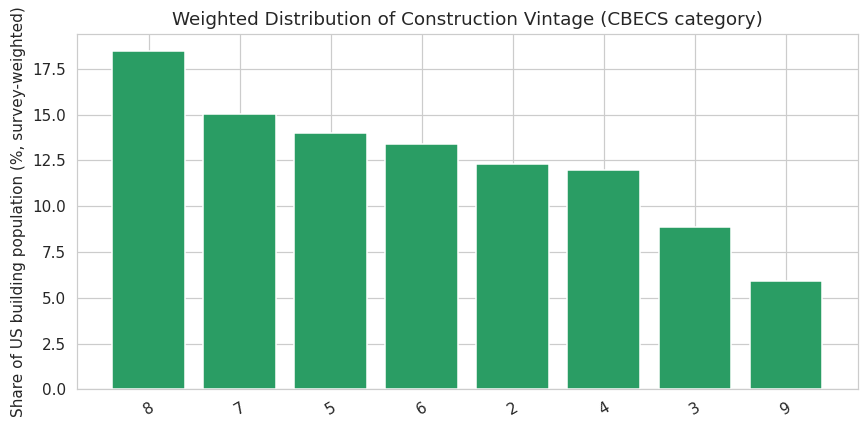

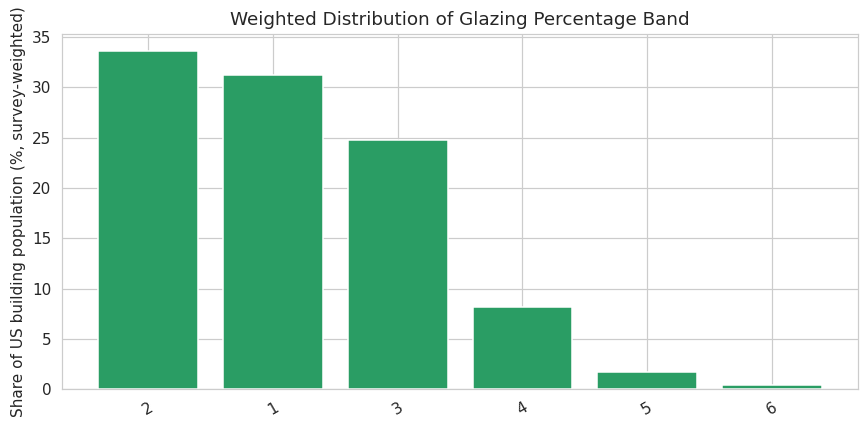

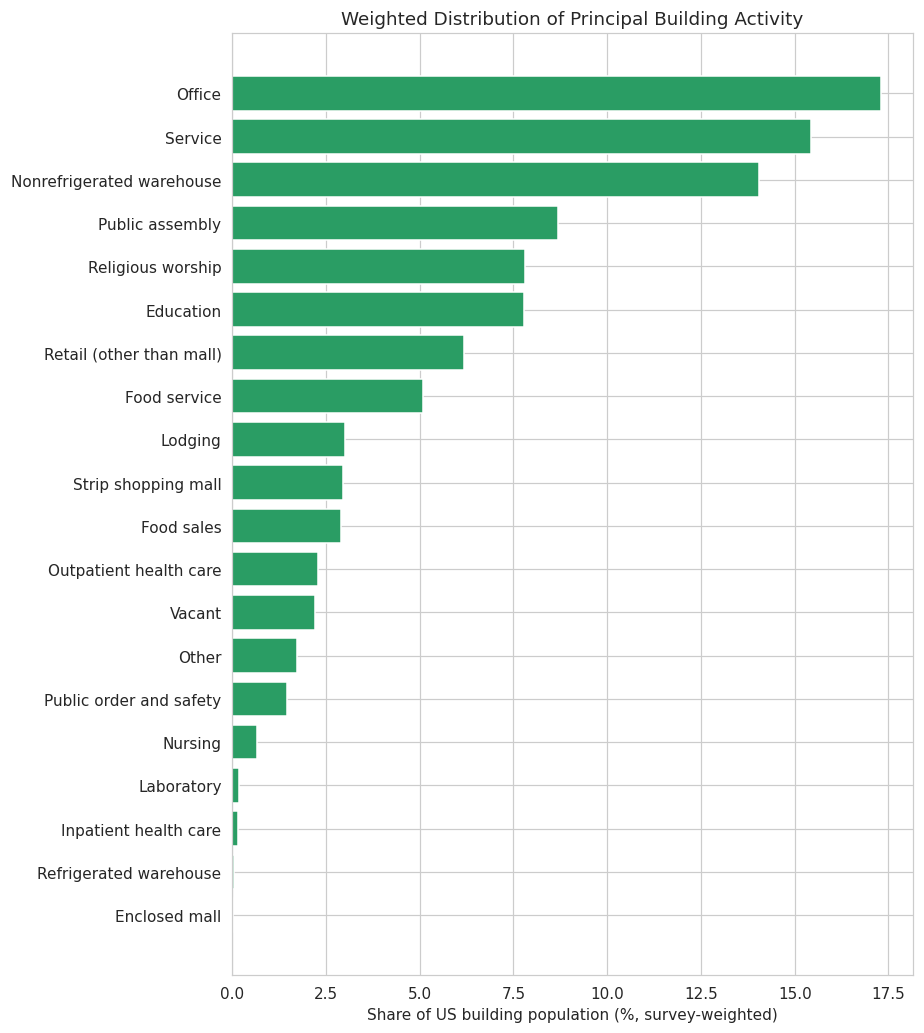

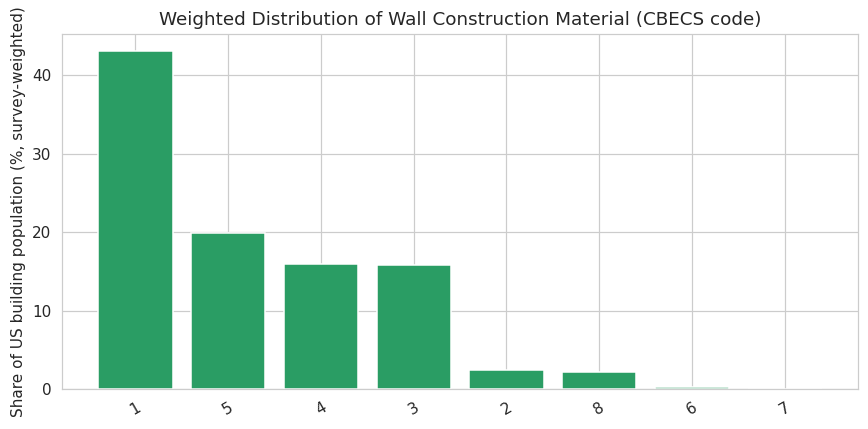

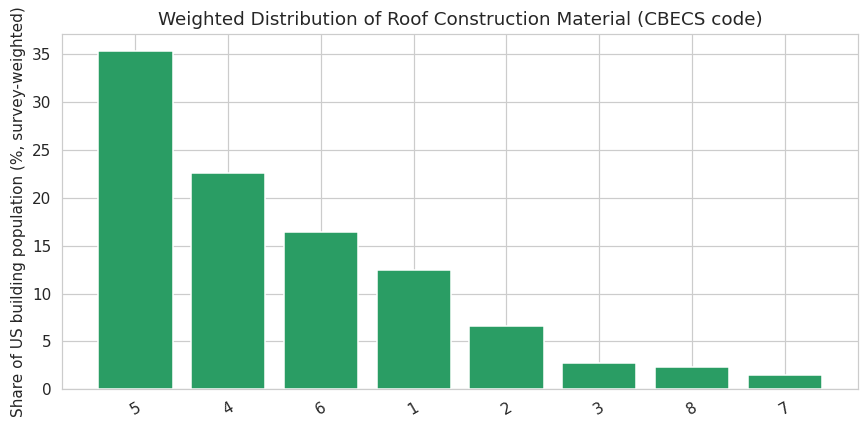

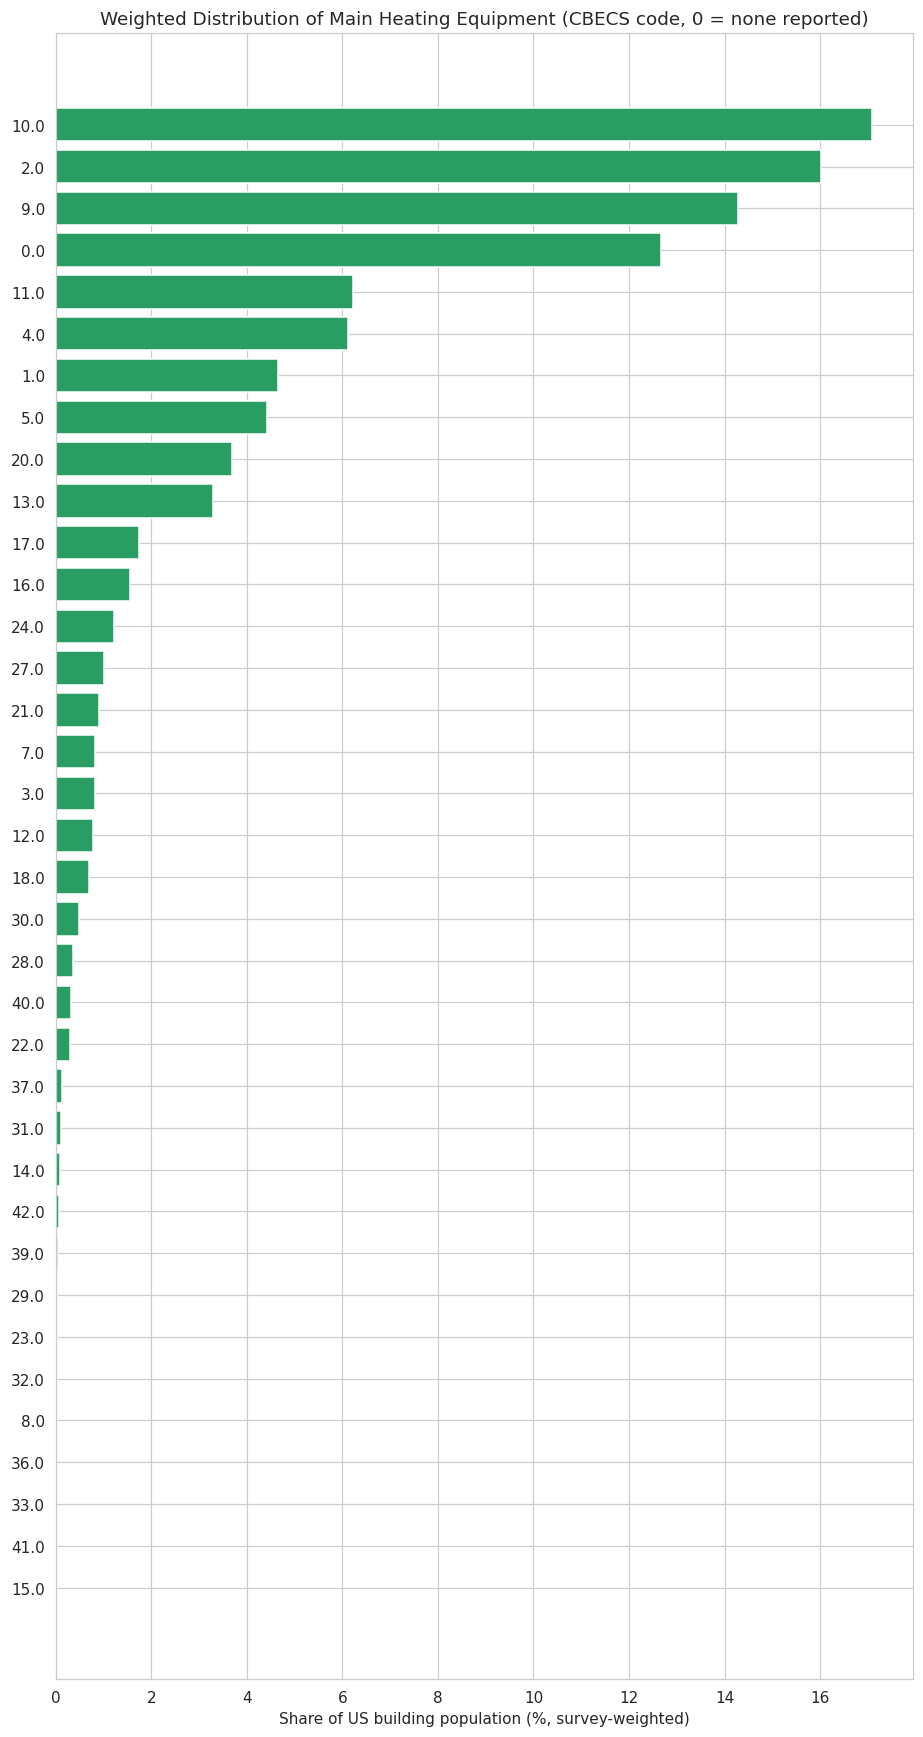

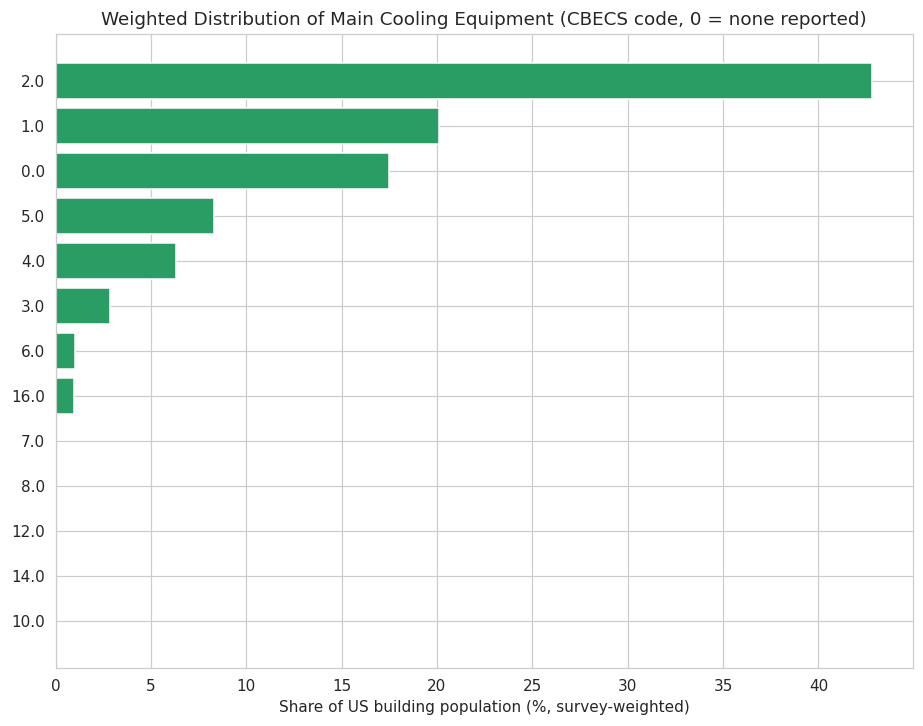

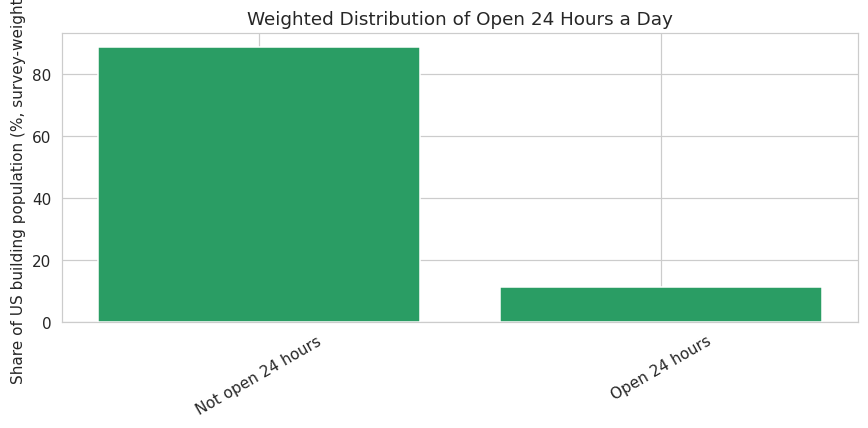

,n_unweighted,weighted_buildings,pct_unweighted,pct_weighted
PBA,,,,
2,1329,970302.56,20.91,17.29
26,349,866297.67,5.49,15.43
5,712,788208.58,11.20,14.04
13,481,488199.37,7.57,8.70
12,271,438605.53,4.26,7.81
14,936,437485.53,14.72,7.79
25,338,346271.63,5.32,6.17
15,218,286466.91,3.43,5.10
18,418,169453.04,6.58,3.02


In [25]:
vars_to_profile = ORDINAL_VARS + NOMINAL_VARS
categorical_tables = {}

for col in vars_to_profile:
    counts = df.groupby(col, observed=True).size().rename("n_unweighted")
    weighted = df.groupby(col, observed=True)[WEIGHT_VAR].sum().rename("weighted_buildings")
    freq = pd.concat([counts, weighted], axis=1)
    freq["pct_unweighted"] = (freq["n_unweighted"] / freq["n_unweighted"].sum() * 100).round(2)
    freq["pct_weighted"] = (freq["weighted_buildings"] / freq["weighted_buildings"].sum() * 100).round(2)
    freq = freq.sort_values("weighted_buildings", ascending=False)
    freq.to_csv(os.path.join(TAB_DIR, f"04_frequency_{col}.csv"))
    categorical_tables[col] = freq

    display_labels = map_labels(col, freq.index)
    many = len(freq) > 8

    if many:
        # Horizontal bars for variables with many categories (e.g. activity),
        # so full category names stay readable.
        fig, ax = plt.subplots(figsize=(8.5, 0.4 * len(freq) + 1.5))
        ax.barh(display_labels[::-1], freq["pct_weighted"][::-1], color=ACCENT_ALT)
        ax.set_xlabel("Share of US building population (%, survey-weighted)")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(display_labels, freq["pct_weighted"], color=ACCENT_ALT)
        ax.set_ylabel("Share of US building population (%, survey-weighted)")
        ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"Weighted Distribution of {label_of(col)}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"04_univariate_{col}.png"))
    plt.show()

categorical_tables["PBA"]

**Observation.** The weighted and unweighted shares diverge exactly the way a stratified sample should. Reading the PBA codes on the chart: offices (code 2) lead the weighted population at 17.29 percent while making up 20.91 percent of raw records, service buildings (code 26) expand from 5.49 percent of the sample to 15.43 percent of the population, and nonrefrigerated warehouses (code 5) hold 14.04 percent weighted. That near-threefold expansion for service buildings means they are under-sampled relative to their population share, and it is the concrete reason FINALWT rather than raw counts must anchor every activity-level statement, including RQ2's two-way ANOVA with activity.

## 6. Bivariate Exploratory Data Analysis

### 6.1 Correlation Matrix

Correlation among continuous predictors and log EUI is the first, cheapest check for multicollinearity: pairs with |r| above about 0.8 here are flagged for a VIF check once the regression is fit, rather than waiting for the regression diagnostics to surface them.

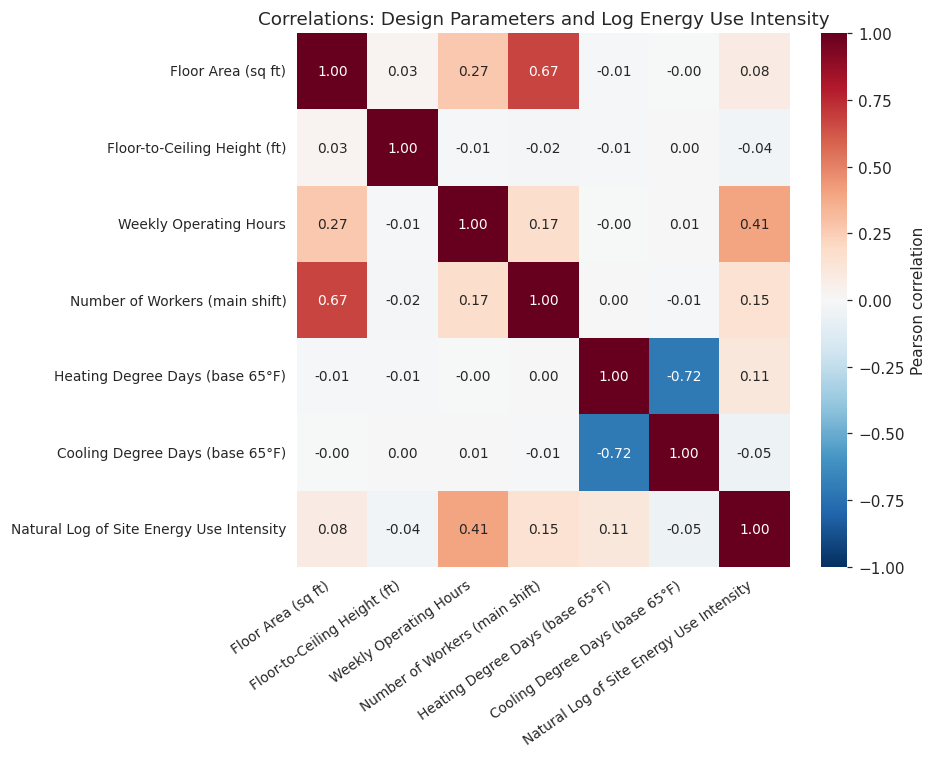

,SQFT,FLCEILHT,WKHRS,NWKER,HDD65,CDD65,log_EUI
SQFT,1.000,0.025,0.270,0.674,-0.008,-0.002,0.084
FLCEILHT,0.025,1.000,-0.012,-0.018,-0.012,0.001,-0.035
WKHRS,0.270,-0.012,1.000,0.174,-0.004,0.006,0.406
NWKER,0.674,-0.018,0.174,1.000,0.002,-0.015,0.149
HDD65,-0.008,-0.012,-0.004,0.002,1.000,-0.716,0.114
CDD65,-0.002,0.001,0.006,-0.015,-0.716,1.000,-0.054
log_EUI,0.084,-0.035,0.406,0.149,0.114,-0.054,1.000


In [26]:
cols = CONTINUOUS_VARS + ["log_EUI"]
corr = df[cols].corr(method="pearson").round(3)
corr.to_csv(os.path.join(TAB_DIR, "05_correlation_matrix.csv"))

corr_display = corr.copy()
corr_display.index = [label_of(c) for c in corr_display.index]
corr_display.columns = [label_of(c) for c in corr_display.columns]

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson correlation"},
            annot_kws={"fontsize": 9})
ax.set_title("Correlations: Design Parameters and Log Energy Use Intensity")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_correlation_heatmap.png"))
plt.show()

corr

**Observation.** Weekly operating hours is the strongest continuous correlate of log EUI at r = 0.406, well ahead of workers (0.149), heating degree days (0.114), and floor area (0.084), an early signal that operational intensity rather than size or climate will likely lead RQ1's ranking. Two pairs deserve collinearity attention once the regression is fit: HDD65 with CDD65 at r = −0.716, expected since cold locations accumulate few cooling degree days, and SQFT with NWKER at 0.674, since larger buildings employ more people. Both sit under the 0.8 screening threshold but close enough to justify a VIF check rather than waiting for unstable coefficients to reveal the problem.

### 6.2 Continuous Predictors vs. Log EUI

A scatterplot of log EUI against each continuous predictor with a fitted linear trend shows whether a relationship is clearly non-linear (and might need a transformation or a spline term) before RQ1's linear model is fit, rather than being discovered only through a residual plot afterward.

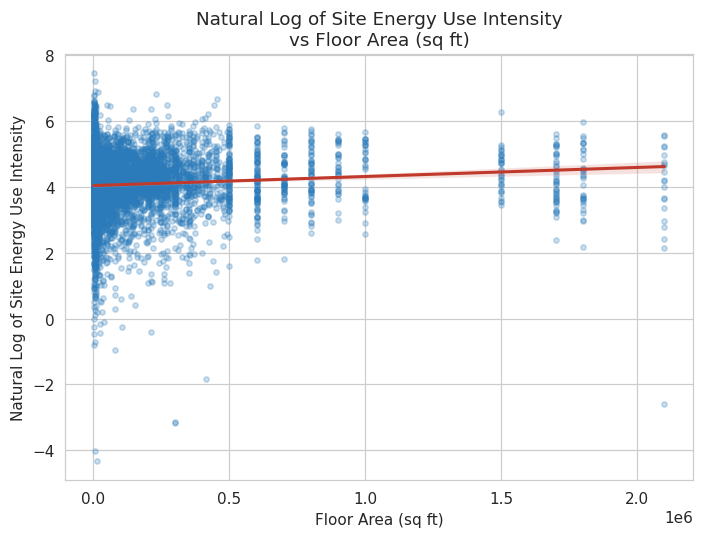

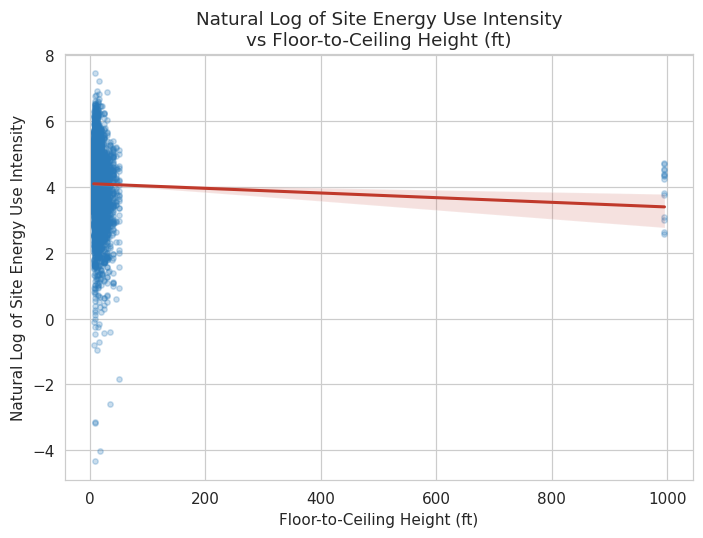

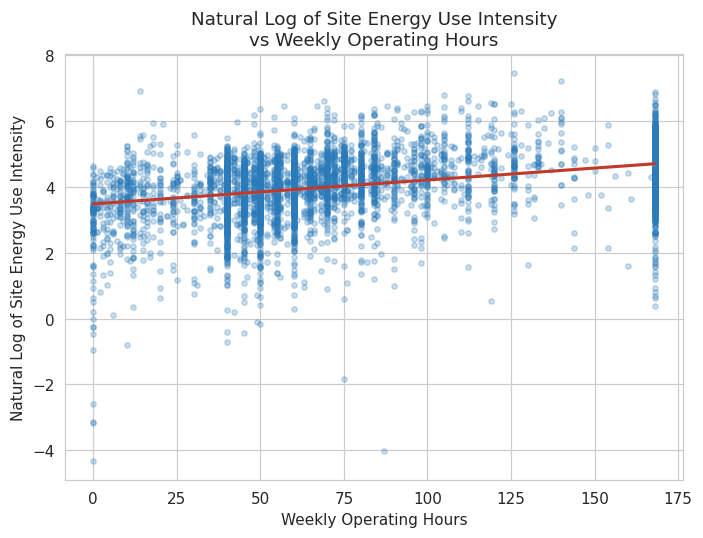

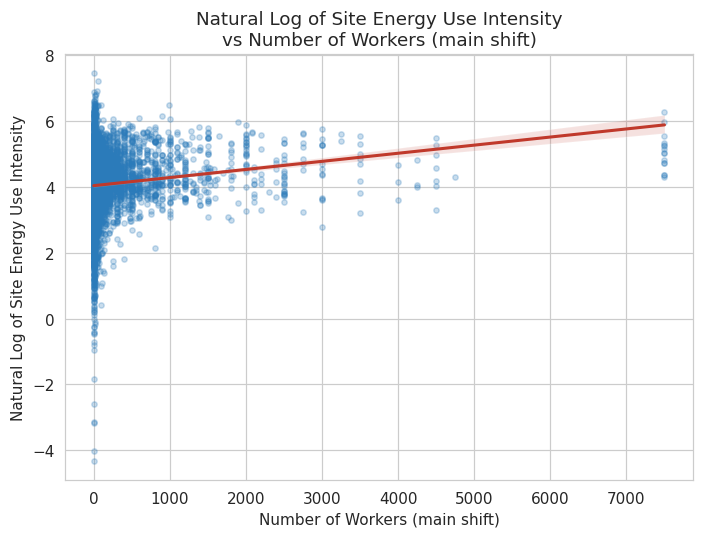

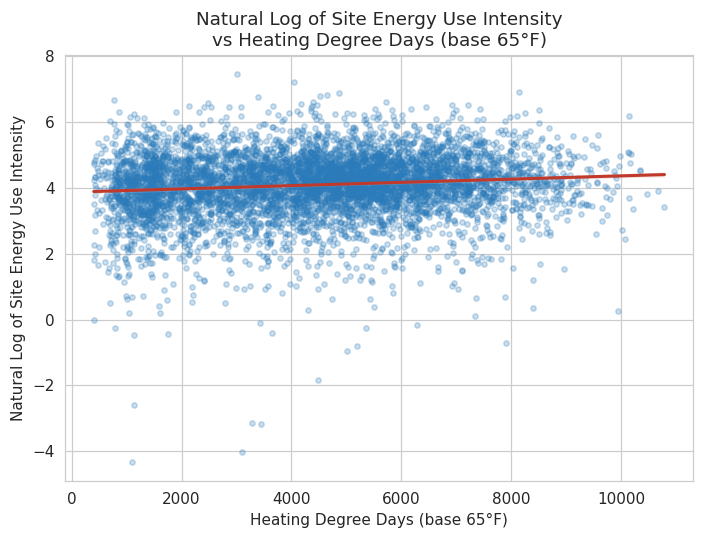

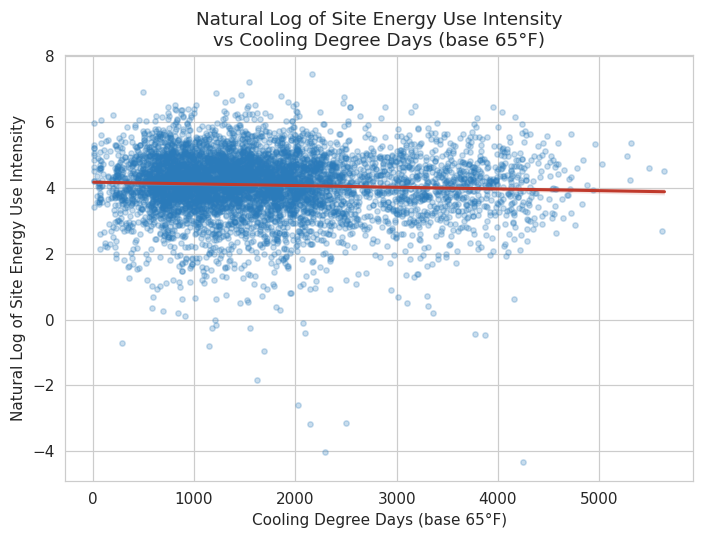

In [27]:
for col in CONTINUOUS_VARS:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.regplot(
        data=df, x=col, y="log_EUI", ax=ax,
        scatter_kws={"alpha": 0.25, "s": 12, "color": ACCENT},
        line_kws={"color": "#c0392b", "lw": 2},
    )
    ax.set_title(f"{label_of('log_EUI')}\nvs {label_of(col)}")
    ax.set_xlabel(label_of(col))
    ax.set_ylabel(label_of("log_EUI"))
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"06_bivariate_{col}_vs_log_EUI.png"))
    plt.show()

**Observation.** The WKHRS panel shows the clearest positive trend, consistent with its correlation, and the vertical band at 168 hours marks the continuously operating buildings. The FLCEILHT panel makes the top-code problem visible as a detached cluster at 995 pulling on the fitted line, exactly the leverage the univariate profile predicted. The remaining predictors are weak or flat at this bivariate level, which does not rule them out for RQ1, since their effects may be conditional on activity, but it does suggest no further transformation is needed beyond the log already applied to EUI.

### 6.3 Categorical Predictors vs. Log EUI

For each categorical or ordinal predictor, a boxplot of log EUI by category shows whether the group differences RQ1 and RQ2 will test are visible even before formal inference, and a survey-weighted group-mean table gives the population-level comparison rather than the unweighted one.

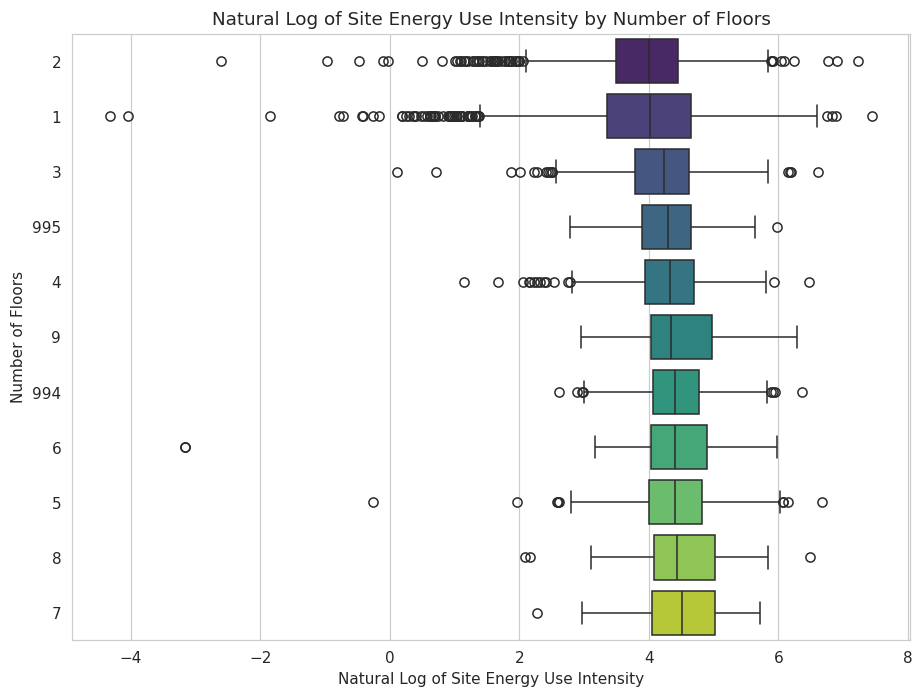

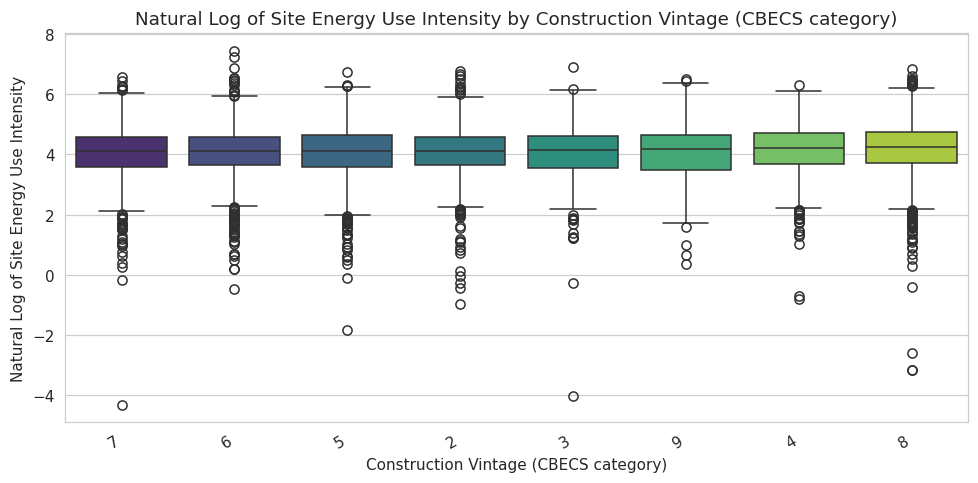

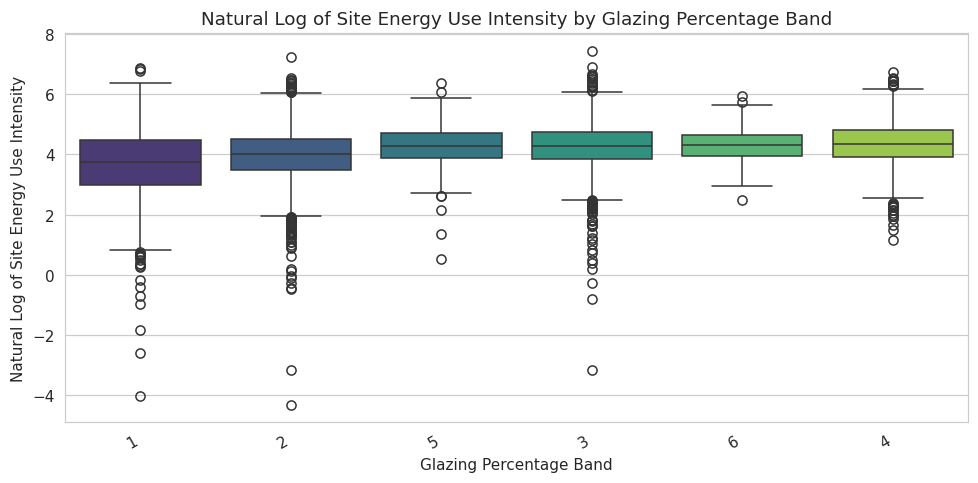

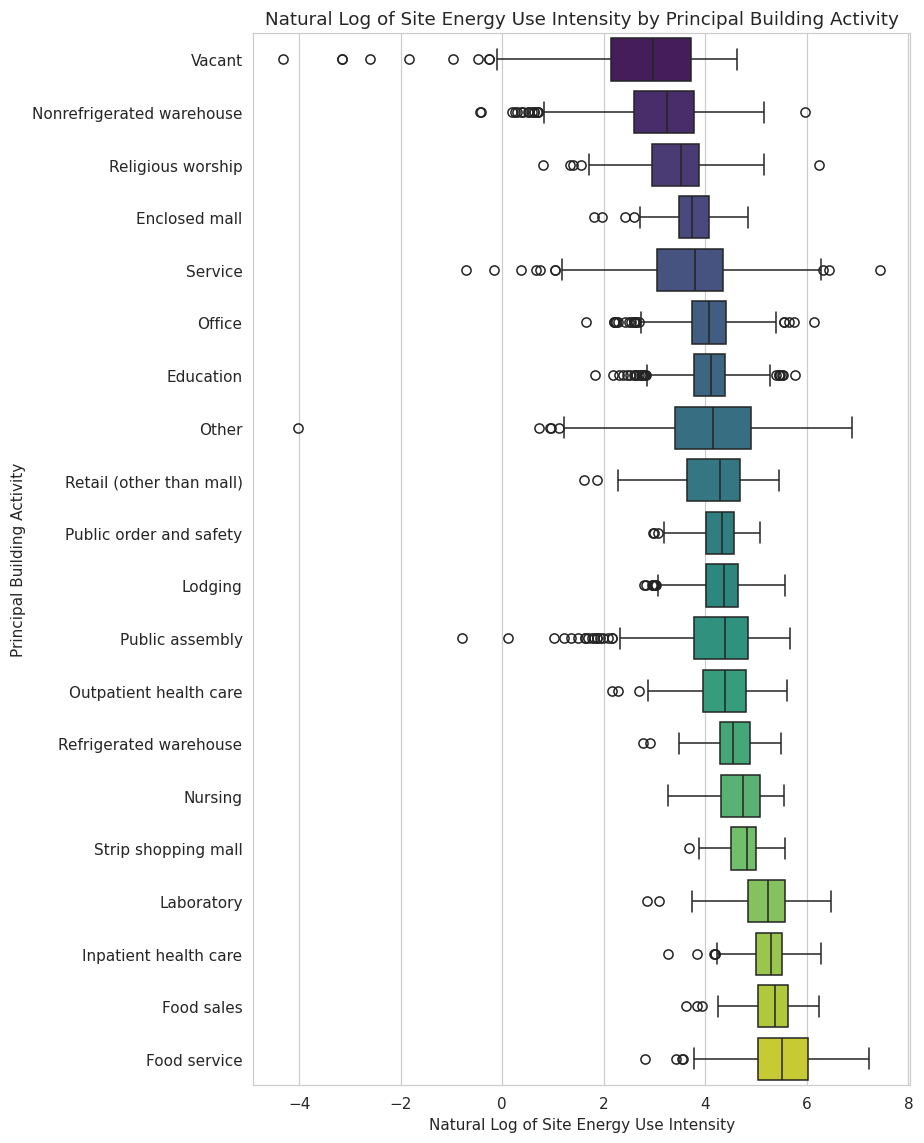

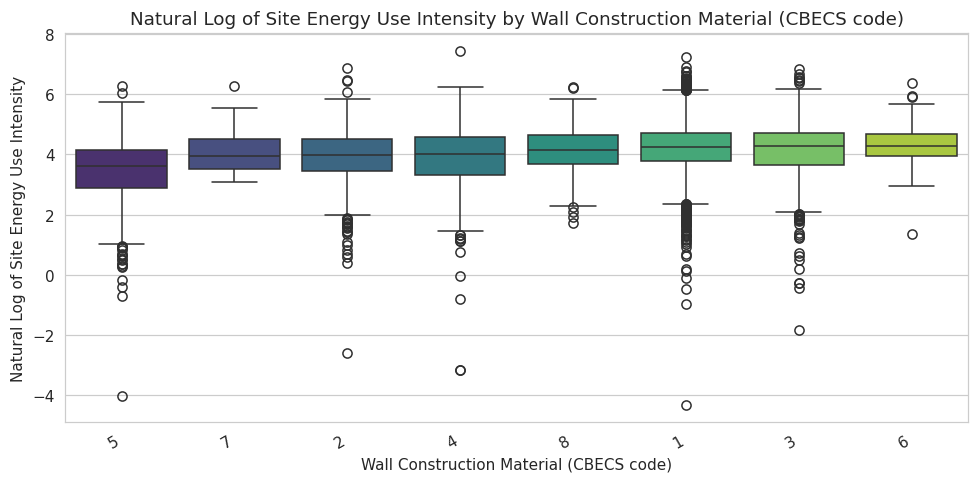

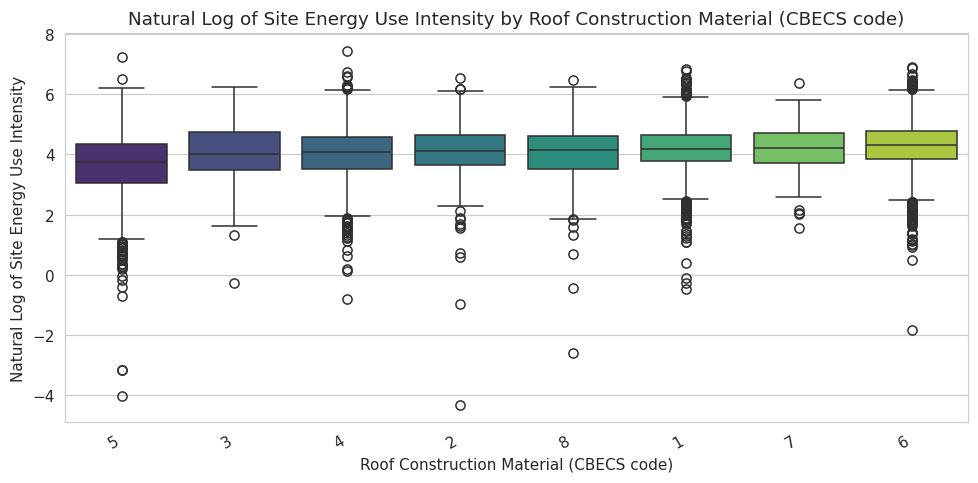

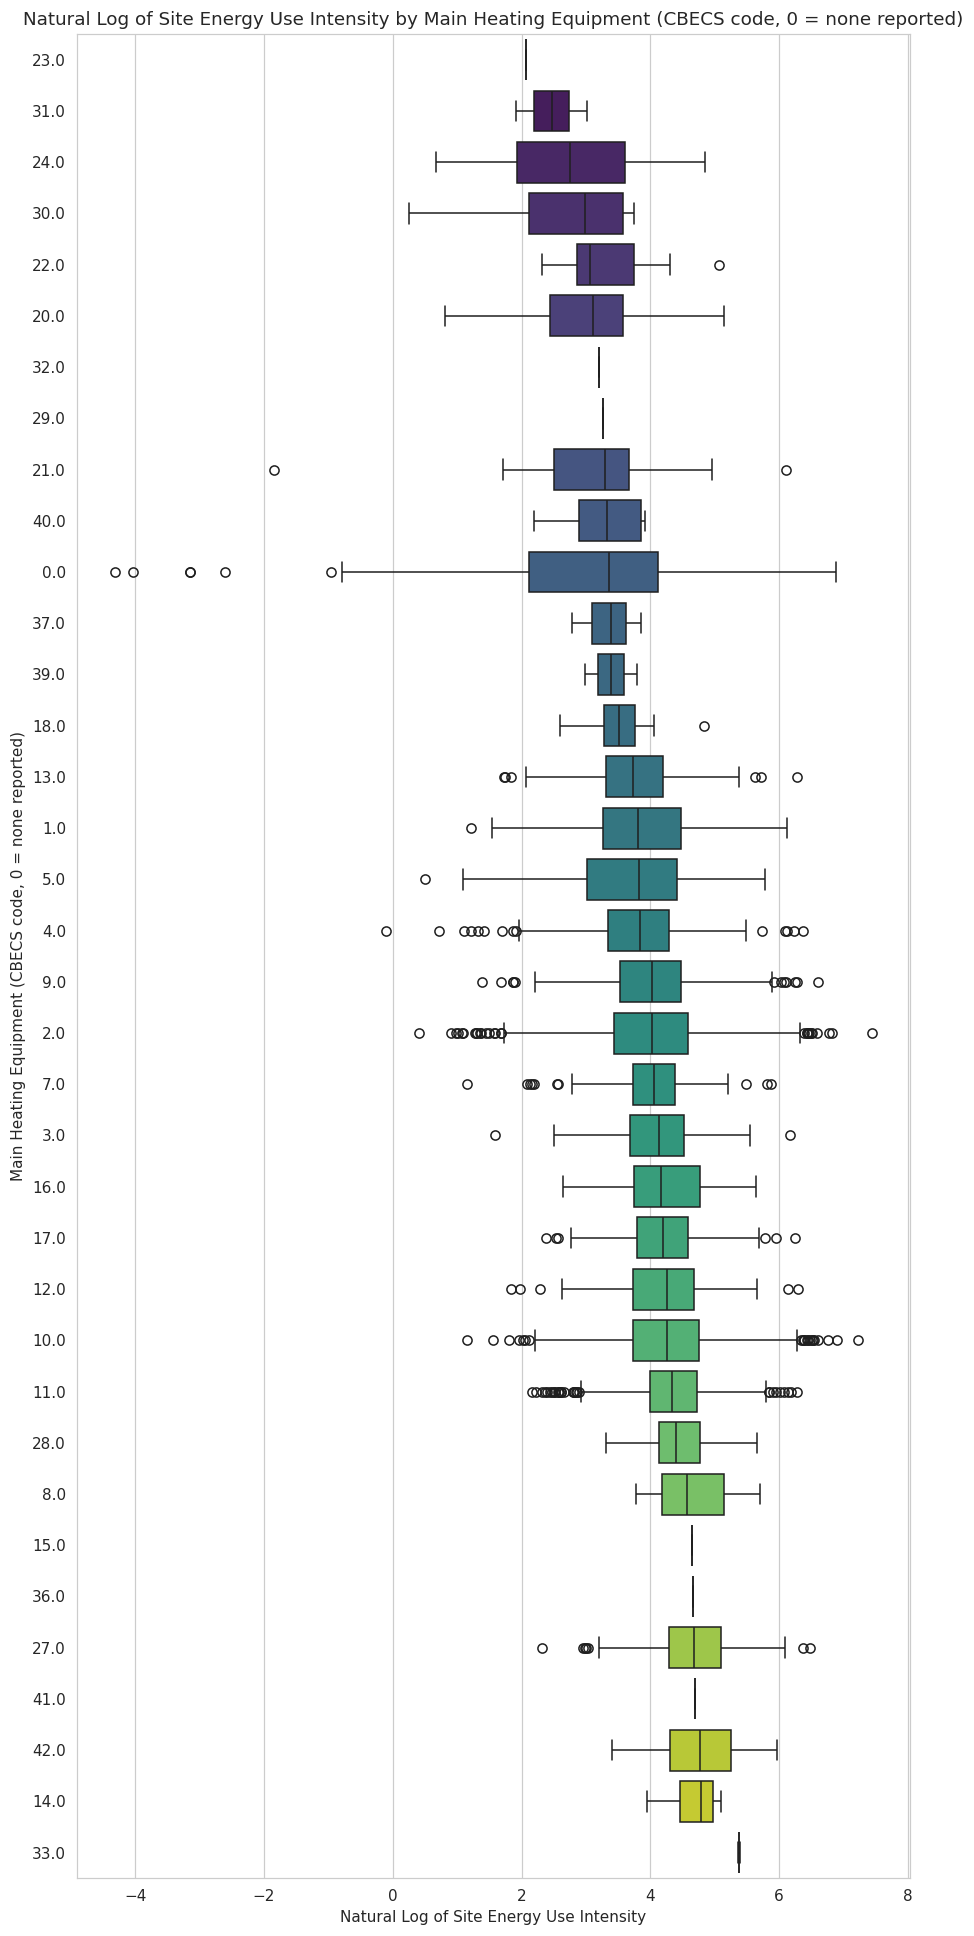

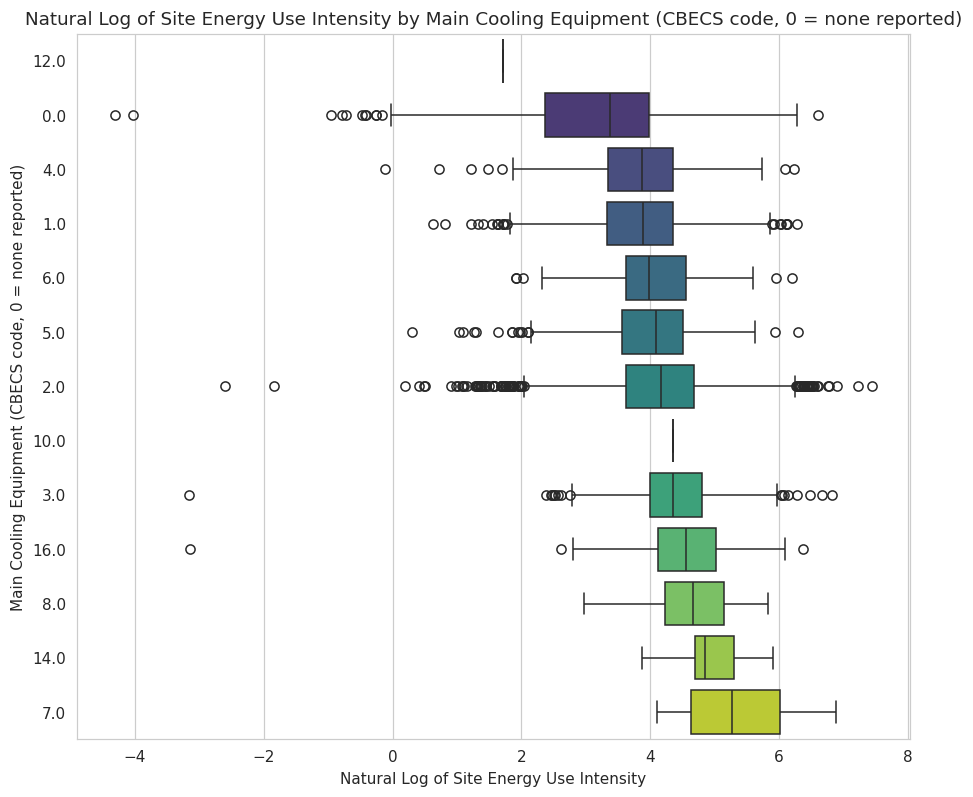

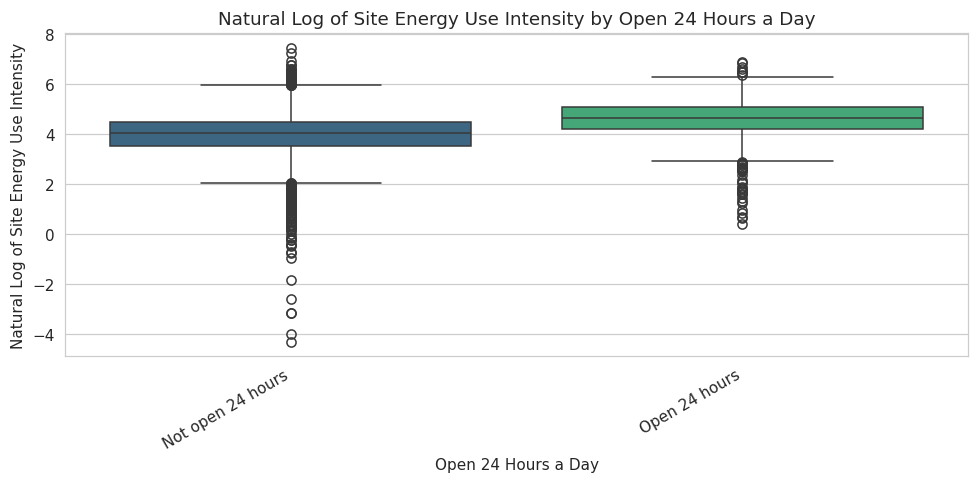

In [28]:
vars_to_profile = ORDINAL_VARS + NOMINAL_VARS

for col in vars_to_profile:
    order = df.groupby(col, observed=True)["log_EUI"].median().sort_values().index
    display_labels = map_labels(col, order)
    many = len(order) > 8

    if many:
        # Horizontal boxplots when there are many categories, so mapped
        # names (e.g. the twenty building activities) stay readable.
        fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(order) + 1.5))
        sns.boxplot(data=df, y=col, x="log_EUI", order=order, ax=ax, orient="h",
                    hue=col, hue_order=order, palette="viridis", legend=False)
        ax.set_yticks(range(len(order)), labels=display_labels)
        ax.set_xlabel(label_of("log_EUI"))
        ax.set_ylabel(label_of(col))
    else:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        sns.boxplot(data=df, x=col, y="log_EUI", order=order, ax=ax,
                    hue=col, hue_order=order, palette="viridis", legend=False)
        ax.set_xticks(range(len(order)), labels=display_labels, rotation=30, ha="right")
        ax.set_xlabel(label_of(col))
        ax.set_ylabel(label_of("log_EUI"))
    ax.set_title(f"{label_of('log_EUI')} by {label_of(col)}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"07_bivariate_{col}_vs_log_EUI.png"))
    plt.show()

    # Survey-weighted group means: np.average with FINALWT as weights,
    # since a simple groupby().mean() would give every building equal
    # weight regardless of how much of the population it represents.
    # Columns are selected before .apply() so the grouping column is not
    # passed into the lambda (avoids the pandas DeprecationWarning).
    weighted_means = (
        df.groupby(col, observed=True)[["log_EUI", WEIGHT_VAR]]
          .apply(lambda g: np.average(g["log_EUI"], weights=g[WEIGHT_VAR]))
          .rename("weighted_mean_log_EUI")
          .sort_values(ascending=False)
    )
    weighted_means.to_csv(os.path.join(TAB_DIR, f"07_weighted_group_means_{col}.csv"))

**Observation.** Activity separates buildings far more than any other categorical predictor: the survey-weighted mean log EUI spans from 5.389 for food service (code 15, roughly 219 kBtu per square foot when back-transformed) down to 2.398 for vacant buildings (code 1, roughly 11), a factor of about twenty. Food sales and inpatient health care sit near the top, warehouses and religious worship near the bottom, which matches the operational intuition that cooking, refrigeration, and round-the-clock care drive intensity. Construction vintage, by contrast, moves the weighted mean by only about 0.27 log units across cohorts, and not monotonically, an early hint that RQ2 will find vintage a real but modest effect once activity is accounted for. Buildings open 24 hours run about 0.24 log units (roughly 26 percent) above the rest, consistent with the operating-hours result above.

## 7. Predictor Matrix Assembly

In [29]:
# Assemble the model-ready predictor matrix shared by RQ1 (survey-weighted
# regression) and RQ3 (ensemble comparison), per the synopsis: continuous
# variables enter as-is, ordinal variables as consecutive rank codes (so
# NFLOOR's 994/995 bands sit as the top two ranks rather than as literal
# floor counts), and nominal variables as one-hot dummies with the first
# level of each dropped as the reference category.
ordinal_X = df[ORDINAL_VARS].astype("category").apply(lambda s: s.cat.codes)
nominal_X = pd.get_dummies(df[NOMINAL_VARS].astype("category"), drop_first=True, dtype=int)
X = pd.concat([df[CONTINUOUS_VARS], ordinal_X, nominal_X], axis=1)
y = df["log_EUI"]

print(f"Predictor matrix: {X.shape[0]:,} buildings x {X.shape[1]} columns")
print(f"  continuous: {len(CONTINUOUS_VARS)} | ordinal (rank-coded): {len(ORDINAL_VARS)} "
      f"| dummies from {len(NOMINAL_VARS)} nominal variables: {nominal_X.shape[1]}")

matrix_path = os.path.join(TAB_DIR, "09_model_ready_predictor_matrix.csv")
pd.concat([df[ID_VARS + [WEIGHT_VAR]], X, y], axis=1).to_csv(matrix_path, index=False)
print(f"Saved model-ready matrix -> {matrix_path}")
X.head()

Predictor matrix: 6,357 buildings x 90 columns
  continuous: 6 | ordinal (rank-coded): 3 | dummies from 6 nominal variables: 81
Saved model-ready matrix -> output/tables/09_model_ready_predictor_matrix.csv


,SQFT,FLCEILHT,WKHRS,NWKER,HDD65,CDD65,NFLOOR,YRCONC,GLSSPC,PBA_2,...,MAINCL_4.0,MAINCL_5.0,MAINCL_6.0,MAINCL_7.0,MAINCL_8.0,MAINCL_10.0,MAINCL_12.0,MAINCL_14.0,MAINCL_16.0,OPEN24_2
0,210000,12,70,350,4463,1759,9,0,2,1,...,0,0,0,0,0,0,0,0,0,1
1,28000,8,45,12,2424,189,4,4,2,1,...,1,0,0,0,0,0,0,0,0,1
2,2100,9,48,6,3218,2403,0,4,2,0,...,0,0,0,0,0,0,0,0,0,1
3,240000,25,55,34,1045,3041,0,7,1,0,...,0,0,0,0,0,0,0,0,0,1
4,295000,30,80,10,5076,1316,0,2,0,0,...,0,0,0,0,0,0,0,0,0,1


**Observation.** The shared matrix comes out at 6,357 buildings by 90 columns: six continuous variables, three rank-coded ordinals, and 81 dummy columns from the six nominal variables (the heating and cooling equipment fields contribute most, at 36 and 13 categories respectively including the explicit “None reported” level). This is the matrix RQ1's regression and RQ3's ensemble comparison will share so their results stay comparable. The one outstanding edit before any model is fit is the FLCEILHT top-code recoding flagged in the cleaning step; it is deliberately left visible here rather than silently patched, since the recoding decision (cap, band, or exclude) belongs to the RQ1 modelling stage.

### 7.1 Staged Feature Engineering for RQ1

The baseline matrix above is the neutral, as-specified predictor set. The engineered variant below is staged for the RQ1 modelling phase: it applies the transformations the synopsis mandates or the EDA motivates, without fitting any model. Three changes, two deliberate abstentions:

1. **ln(SQFT)** replaces raw floor area, matching the synopsis's RQ1 equation (ln EUI on ln SQFT) and fixing the skew.
2. **FLCEILHT top-code resolved**: the fourteen 995 codes are capped at 50 (their documented meaning, "more than 50 feet") with a binary `ceiling_over_50ft` flag preserving the information that these buildings are exceptional.
3. **Worker density** (workers per 1,000 sq ft) replaces the raw worker count, converting an absolute-size proxy into an operational-intensity measure and removing its collinearity with floor area.

*Not* engineered, deliberately: the HDD65/CDD65 pair stays as-is pending the RQ1 VIF check, and no interaction or polynomial terms are added, since the RQ1 sizing rests on k = 12 predictors and RQ3's ensembles are meant to learn non-linearities themselves.

In [30]:
# Engineered matrix staged for RQ1. Built alongside (not replacing) the
# baseline matrix so both remain inspectable and the RQ3 comparison can be
# run on either specification.
eng = pd.DataFrame(index=df.index)
eng["ln_SQFT"] = np.log(df["SQFT"])
eng["FLCEILHT_capped"] = df["FLCEILHT"].clip(upper=50)
eng["ceiling_over_50ft"] = (df["FLCEILHT"] == 995).astype(int)
eng["worker_density_per_1000sqft"] = df["NWKER"] / df["SQFT"] * 1000
eng["WKHRS"] = df["WKHRS"]
eng["HDD65"] = df["HDD65"]   # kept raw pending the RQ1 VIF check
eng["CDD65"] = df["CDD65"]   # kept raw pending the RQ1 VIF check

X_rq1 = pd.concat([eng, ordinal_X, nominal_X], axis=1)

from scipy import stats as _st
print(f"Engineered RQ1 matrix: {X_rq1.shape[0]:,} buildings x {X_rq1.shape[1]} columns "
      f"(baseline was {X.shape[1]})")
print(f"Skewness  SQFT {_st.skew(df['SQFT']):.2f} -> ln_SQFT {_st.skew(eng['ln_SQFT']):.2f}")
print(f"Skewness  FLCEILHT {_st.skew(df['FLCEILHT']):.2f} -> capped {_st.skew(eng['FLCEILHT_capped']):.2f}")
print(f"Skewness  NWKER {_st.skew(df['NWKER']):.2f} -> worker density {_st.skew(eng['worker_density_per_1000sqft']):.2f}")
print(f"Collinearity  corr(NWKER, SQFT) = {df['NWKER'].corr(df['SQFT']):.3f} -> "
      f"corr(density, ln_SQFT) = {eng['worker_density_per_1000sqft'].corr(eng['ln_SQFT']):.3f}")
print(f"Association with log EUI  raw NWKER r = {df['NWKER'].corr(df['log_EUI']):.3f} -> "
      f"density r = {eng['worker_density_per_1000sqft'].corr(df['log_EUI']):.3f}")

rq1_path = os.path.join(TAB_DIR, "10_rq1_engineered_predictor_matrix.csv")
pd.concat([df[ID_VARS + [WEIGHT_VAR]], X_rq1, y], axis=1).to_csv(rq1_path, index=False)
print(f"Saved engineered matrix -> {rq1_path}")

Engineered RQ1 matrix: 6,357 buildings x 91 columns (baseline was 90)
Skewness  SQFT 3.76 -> ln_SQFT -0.34
Skewness  FLCEILHT 20.49 -> capped 2.24
Skewness  NWKER 7.32 -> worker density 2.12
Collinearity  corr(NWKER, SQFT) = 0.674 -> corr(density, ln_SQFT) = -0.107
Association with log EUI  raw NWKER r = 0.149 -> density r = 0.267
Saved engineered matrix -> output/tables/10_rq1_engineered_predictor_matrix.csv


**Observation.** Every engineered change earns its place in the numbers. The log transform takes floor area's skewness from 3.76 to −0.34; capping the fourteen top-coded ceiling heights at their documented meaning takes FLCEILHT from 20.49 to 2.24, in line with the other predictors, while the `ceiling_over_50ft` flag keeps those buildings identifiable; and worker density both behaves better than the raw count (skewness 7.32 down to 2.12) and matters more, with its correlation to log EUI rising from 0.149 to 0.267 while its collinearity with floor area collapses from 0.674 to −0.107. This also closes the FLCEILHT recoding item flagged as in progress at the interim report: the resolution is cap-plus-flag rather than exclusion, so no records are lost and the RQ4 sample-size margin is untouched. The matrix grows by exactly one column (90 to 91), well within the study's sizing headroom, and both matrices are saved so RQ1 can be fit on the engineered specification while RQ3's ensemble-versus-baseline comparison stays runnable on either.

## 8. Export Cleaned Dataset

The cleaned analysis dataset is written alongside the figures and tables so that RQ1–RQ4 modelling notebooks can load it directly rather than repeating the cleaning steps above.

In [31]:
cleaned_path = os.path.join(TAB_DIR, "00_cleaned_analysis_dataset.csv")
df.to_csv(cleaned_path, index=False)
print(f"Cleaned sample: {len(df)} buildings written to {cleaned_path}")

Cleaned sample: 6357 buildings written to output/tables/00_cleaned_analysis_dataset.csv


In [32]:
os.chdir("/content/repo")
os.system("git add notebooks/cbecs_eda_pipeline.ipynb output/")
os.system("git status --short")   # sanity check before committing
os.system('git commit -m "Colab run: regenerate EDA figures and tables"')
os.system("git push origin main")

0